## Project 1: Bluebikes Station Imbalance Analysis


### Your name: 

## Maithili Rajendra Wade

## Project Background

Bluebikes began in 2011 as Hubway, launching with 60 stations in Boston. It has since grown into a large regional bike-sharing system with nearly 400 stations and 4,000 bikes across 10 municipalities. In this project, you will use real Bluebikes data to investigate whether station bike availability behaves differently during the morning commute and evening commute, and whether these patterns show meaningful spatial structure across the city.

### Data Sources

Use the following data:

- Bluebikes trip data for August, September, and October 2025
- https://s3.amazonaws.com/hubway-data/index.html
- Bluebikes system/station website to understand the meaning of the features and fields.
- https://bluebikes.com/system-data


You should download and study the data specified in the project description.

### Main Question

Do Boston Bluebikes stations show significant differences in bike storage behavior between:

- Morning peak: 7:00-9:00 AM
- Evening peak: 4:00-7:00 PM
  

You must address the following:

1. Morning vs. Evening Difference
  - Is there a significant difference in station-level bike storage behavior between morning peak and evening peak?
2. Empty-Station Risk
  - Which stations are more likely to become “empty” during the morning peak?
  - Interpret “empty” as a station likely to experience a shortage of available bikes.
3. Full-Station Risk
  - Which stations are more likely to become “full” during the evening peak?
  - Interpret “full” as a station likely to experience a shortage of available docks.
4. Spatial Clustering
  - Do these phenomena show spatial clustering?
  - For example, do patterns differ between downtown/commercial areas and residential areas?
5. Visualization
  - Use standard visualization methods to communicate your results clearly.


### Optional Extensions

If you can't solve the above questions well, you can also explore other interesting problems supported by data features. As long as these problems are based on data and have good reasoning, they can also help you get a good score.


### Bonus Question

Map-based visualization:
- Display your findings on a map, highlighting in particular the risk of empty stations in the morning, full stations in the evening, or supply-demand imbalances during peak hours at the station level.

## Suggested Technical Workflow

Students may use:
- Python
- pandas
- numpy
- matplotlib / seaborn / plotly
- geopandas / folium / plotly mapbox for maps if desired


A reasonable workflow is:

- Load August, September, October 2025 files
- Merge and clean
- Parse timestamps
- Filter Boston-area or all Bluebikes stations, depending on your chosen scope
- Extract morning and evening peak trips
- Compute departures, arrivals, and net flow by station
- Rank stations by imbalance
- Compare patterns across time windows
- Visualize results
- Interpret spatial structure
- ....

# Your work:

In [1]:
#imports
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
#loading the datasets
df_aug = pd.read_csv("202508-bluebikes-tripdata.csv")
df_sep = pd.read_csv("202509-bluebikes-tripdata.csv")
df_oct = pd.read_csv("202510-bluebikes-tripdata.csv")

In [3]:
df_aug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549014 entries, 0 to 549013
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             549014 non-null  object 
 1   rideable_type       549014 non-null  object 
 2   started_at          549014 non-null  object 
 3   ended_at            549014 non-null  object 
 4   start_station_name  548800 non-null  object 
 5   start_station_id    548800 non-null  object 
 6   end_station_name    548072 non-null  object 
 7   end_station_id      548010 non-null  object 
 8   start_lat           549014 non-null  float64
 9   start_lng           549014 non-null  float64
 10  end_lat             548686 non-null  float64
 11  end_lng             548686 non-null  float64
 12  member_casual       549014 non-null  object 
dtypes: float64(4), object(9)
memory usage: 54.5+ MB


In [4]:
df_sep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586979 entries, 0 to 586978
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             586979 non-null  object 
 1   rideable_type       586979 non-null  object 
 2   started_at          586979 non-null  object 
 3   ended_at            586979 non-null  object 
 4   start_station_name  586815 non-null  object 
 5   start_station_id    586815 non-null  object 
 6   end_station_name    586108 non-null  object 
 7   end_station_id      586068 non-null  object 
 8   start_lat           586979 non-null  float64
 9   start_lng           586979 non-null  float64
 10  end_lat             586610 non-null  float64
 11  end_lng             586610 non-null  float64
 12  member_casual       586979 non-null  object 
dtypes: float64(4), object(9)
memory usage: 58.2+ MB


In [5]:
df_oct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513531 entries, 0 to 513530
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             513531 non-null  object 
 1   rideable_type       513531 non-null  object 
 2   started_at          513531 non-null  object 
 3   ended_at            513531 non-null  object 
 4   start_station_name  513333 non-null  object 
 5   start_station_id    513333 non-null  object 
 6   end_station_name    512840 non-null  object 
 7   end_station_id      512772 non-null  object 
 8   start_lat           513531 non-null  float64
 9   start_lng           513531 non-null  float64
 10  end_lat             513287 non-null  float64
 11  end_lng             513287 non-null  float64
 12  member_casual       513531 non-null  object 
dtypes: float64(4), object(9)
memory usage: 50.9+ MB


In [6]:
#merging all the datasets
df = pd.concat([df_aug, df_sep, df_oct], ignore_index=True)
print("Before cleaning:", df.shape)

Before cleaning: (1649524, 13)


In [7]:
#dropping rows missing values 
df = df.dropna(subset=["start_station_id", "end_station_id", "start_station_name", "end_station_name"])
print("After cleaning: ", df.shape)

After cleaning:  (1646387, 13)


In [8]:
#parsing timestamps
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

#extracting hour from departure time 
df["start_hour"] = df["started_at"].dt.hour

print(df.dtypes)
print(df["start_hour"].value_counts().sort_index())

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
start_hour                     int32
dtype: object
start_hour
0      19646
1      13865
2       7907
3       2879
4       3061
5      10044
6      26973
7      64368
8     108776
9      81604
10     70684
11     77700
12     89702
13     92561
14     96723
15    109715
16    138583
17    172242
18    140814
19    106526
20     75274
21     59127
22     46179
23     31434
Name: count, dtype: int64


**Peak Hour Definition** 
- Morning peak: Hours 7 and 8 (7:00 AM - 8:59 AM), covering the 7:00-9:00 AM window
- Evening peak: Hours 16, 17 and 18 (4:00 PM - 6:59 PM), covering 4:00-7:00 PM window

Note: Since 'start_hour' represents the hour block (e.g., hour 8 = 8:00–8:59 AM),
filtering hours 7–8 correctly captures all trips departing within the 7:00–9:00 AM 
window, and hours 16–18 capture all trips within the 4:00–7:00 PM window.

In [9]:
#filtering peak hours and computing net flow 

#filtering morning peak: 7-9am
morning = df[df["start_hour"].between(7, 8)]

#filtering evening peak: 4-7pm
evening = df[df["start_hour"].between(16, 18)]

print("Morning trips:", len(morning))
print("Evening trips:", len(evening))
#for morning
#departures per station (morning)
morning_dep = morning.groupby("start_station_name").size().rename("departures")

#arrivals per station (morning)
morning_arr = morning.groupby("end_station_name").size().rename("arrivals")

#Combine into one DataFrame
morning_flow = pd.concat([morning_dep, morning_arr], axis=1).fillna(0)
morning_flow["net_flow"] = morning_flow["arrivals"] - morning_flow["departures"]

#for evening 
#departures evening 
evening_dep = evening.groupby("start_station_name").size().rename("departures")

#evening arrivals 
evening_arr = evening.groupby("end_station_name").size().rename("arrivals")

#combining into one df 
evening_flow = pd.concat([evening_dep, evening_arr], axis=1).fillna(0)
evening_flow["net_flow"] = evening_flow["arrivals"] - evening_flow["departures"]

print(morning_flow.sort_values("net_flow").head(5))
print(evening_flow.sort_values("net_flow", ascending=False).head(5))


Morning trips: 173144
Evening trips: 451639
                                               departures  arrivals  net_flow
MIT Vassar St                                      2980.0     561.0   -2419.0
W Broadway at D St                                 1220.0     295.0    -925.0
Nashua Street at Red Auerbach Way                  1189.0     292.0    -897.0
Inman Square at Springfield St.                    1326.0     477.0    -849.0
Nashua Street at Red Auerbach Way [Extension]      1032.0     183.0    -849.0
                                               departures  arrivals  net_flow
MIT Vassar St                                        4340      5909      1569
Nashua Street at Red Auerbach Way                    1049      2213      1164
Inman Square at Springfield St.                      1660      2742      1082
Nashua Street at Red Auerbach Way [Extension]         724      1763      1039
Valenti Way at Haverhill St                          1422      2319       897


##  1. Morning vs. Evening Difference
### Is there a significant difference in station-level bike storage behavior between morning peak and evening peak?

In [10]:
#getting stations in both the flows 
morning_flow["total"] = morning_flow["departures"] + morning_flow["arrivals"]
evening_flow["total"] = evening_flow["departures"] + evening_flow["arrivals"]

#netflow rate 
morning_flow["net_flow_rate"] = morning_flow["net_flow"] / morning_flow["total"]
evening_flow["net_flow_rate"] = evening_flow["net_flow"] / evening_flow["total"]

common_stations = morning_flow.index.intersection(evening_flow.index)

morning_rate = morning_flow.loc[common_stations, "net_flow_rate"]
evening_rate = evening_flow.loc[common_stations, "net_flow_rate"]

t_stat, p_value = stats.ttest_rel(morning_rate, evening_rate)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Morning avg net flow rate: {morning_rate.mean():.4f}")
print(f"Evening avg net flow rate: {evening_rate.mean():.4f}")

T-statistic: -6.9835
P-value: 0.000000
Morning avg net flow rate: -0.1413
Evening avg net flow rate: 0.0355


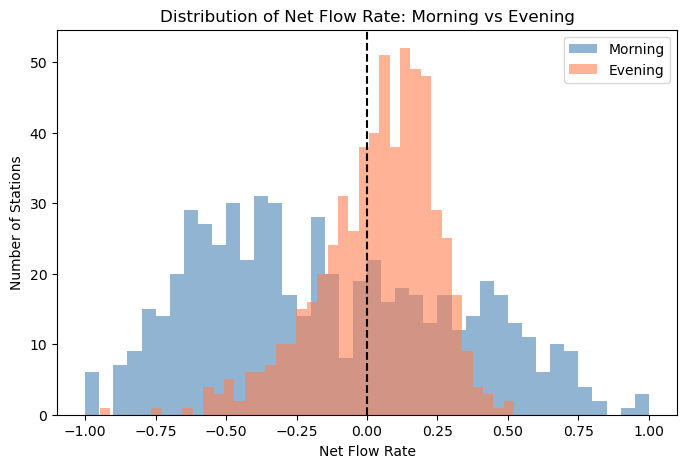

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(morning_rate, bins=40, alpha=0.6, label="Morning", color="steelblue")
plt.hist(evening_rate, bins=40, alpha=0.6, label="Evening", color="coral")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Net Flow Rate")
plt.ylabel("Number of Stations")
plt.title("Distribution of Net Flow Rate: Morning vs Evening")
plt.legend()
plt.show()

### Result

There is a **highly significant difference** in station-level bike storage behavior between morning and evening peaks (t = -6.98, p ≈ 0.000). 

- During **morning peak (7-9am)**, stations show an average net flow rate of **-0.14**, meaning bikes drain out faster than they arrive - consistent with commuters departing residential and campus areas toward work destinations.
- During **evening peak (4-7pm)**, the average net flow rate flips to **+0.04**, meaning bikes accumulate at destination stations as commuters return home.

This directional reversal confirms a clear commuter imbalance pattern across the BlueBikes System. Stations that empty in the morning tend to fill in the evening, creating a predictable supply-demand cycle that poses operational challenges for BlueBikes rebalancing teams. 

# 2. Empty-Station Risk
## Which stations are more likely to become “empty” during the morning peak?
## Interpret “empty” as a station likely to experience a shortage of available bikes.

In [12]:
#working with morning flow, reseting index for easier handling 
morning_risk = morning_flow.copy().reset_index()
morning_risk.columns = ["station", "departures", "arrivals", "net_flow", "total", "net_flow_rate"]


In [13]:
#Empty risk = most negative net flow rate 
empty_risk = morning_risk[morning_risk["total"] >= 100].sort_values("net_flow_rate").head(15)

print(empty_risk[["station", "departures", "arrivals", "net_flow", "net_flow_rate"]])

                                               station  departures  arrivals  \
414           Oak Square - Washington St at Bigelow St       190.0      11.0   
391                  NCAAA - Walnut Ave at Crawford St       143.0       9.0   
376                            Medford St at Warren St       108.0       8.0   
548                   Walbridge St at Commonwealth Ave       580.0      48.0   
205                   Dorchester Ave at Savin Hill Ave       106.0      11.0   
355                              Marion St at White St       171.0      18.0   
143                              Chelsea St at Vine St       118.0      13.0   
212            Edwards Playground - Main St at Eden St       471.0      52.0   
519                     The Eddy - New St at Sumner St       134.0      15.0   
551                            Walnut Ave at Warren St       299.0      34.0   
463  Ryan Playground - Dorchester Ave at Harbor Vie...       340.0      39.0   
521                      The Overlook at

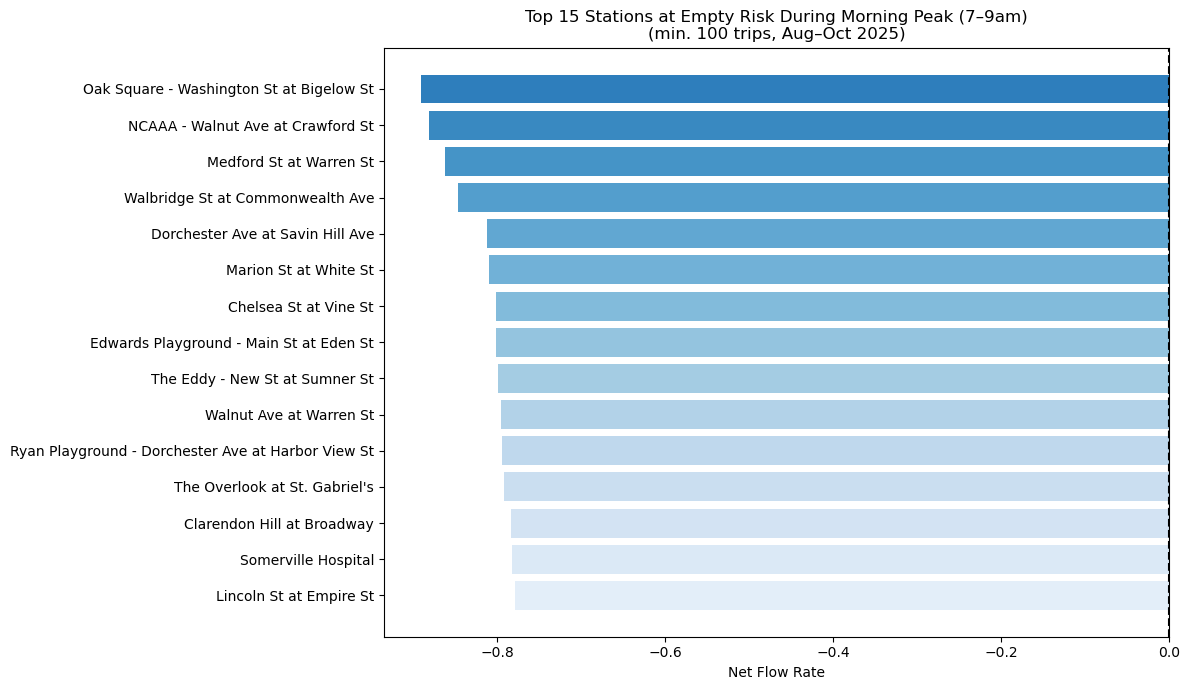

In [28]:
fig, ax = plt.subplots(figsize=(12, 7))

# Color gradient — darkest for worst risk
colors = cm.Blues_r(np.linspace(0.3, 0.9, len(empty_risk)))
ax.barh(empty_risk["station"], empty_risk["net_flow_rate"], color=colors)
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel("Net Flow Rate")
ax.set_title("Top 15 Stations at Empty Risk During Morning Peak (7–9am)\n(min. 100 trips, Aug–Oct 2025)")
ax.invert_yaxis()
plt.subplots_adjust(left=0.45)  # fixes cut-off station names
plt.tight_layout()
plt.show()


## Conclusion:

Stations at highest empty risk during morning peak (7-9am) are concentrated in **outer residential neighborhoods** - Dorchester, Jamaica Plain, Chelsea and Somerville. 

Top stations by empty risk (min. 100 trips, net flow rate):

| Station | Departures | Arrivals | Net Flow Rate |
|---|---|---|---|
| Oak Square - Washington St at Bigelow St | 190 | 11 | -0.89 |
| NCAAA - Walnut Ave at Crawford St | 143 | 9 | -0.88 |
| Walbridge St at Commonwealth Ave | 580 | 48 | -0.85 |
| Edwards Playground - Main St at Eden St | 471 | 52 | -0.80 |

These stations acts as ** commuter origin points** - riders depart in the morning toward work/school destinations but very few bikes arrive to replenish supply. 

Walbridge st. has the highest raw outflow (532 net blikes lost in just 2 hours), making it the single highest rebalancing priority in the morning window. 

# 3. Full-Station Risk
## Which stations are more likely to become “full” during the evening peak?
## Interpret “full” as a station likely to experience a shortage of available docks.

In [15]:
#Evening flow 
evening_risk = evening_flow.copy().reset_index()
evening_risk.columns = ["station", "departures", "arrivals", "net_flow", "total", "net_flow_rate"]

#full risk - most positive net flow rate, min 100 trips 
full_risk = evening_risk[evening_risk["total"] >= 100].sort_values("net_flow_rate", ascending=False).head(15)

print(full_risk[["station", "departures", "arrivals", "net_flow", "net_flow_rate"]])

                                           station  departures  arrivals  \
407                Northbourne Rd at Hyde Park Ave          33       105   
456                  Roslindale Village - South St          95       292   
457             Roslindale Village - Washington St          68       179   
365                         Mass Ave at Grafton St         108       273   
34                      Alpine Path at Concord Ave          49       122   
396  Nashua Street at Red Auerbach Way [Extension]         724      1763   
263                                      Hale Park          40        93   
479                   Shawmut Ave at E Berkeley St         253       584   
356                               Maplewood Square          66       147   
213                       Edgerly Education Center         423       913   
417       Oak Square - Washington St at Bigelow St         163       350   
65                     Belgrade Ave at Walworth St          36        77   
395         

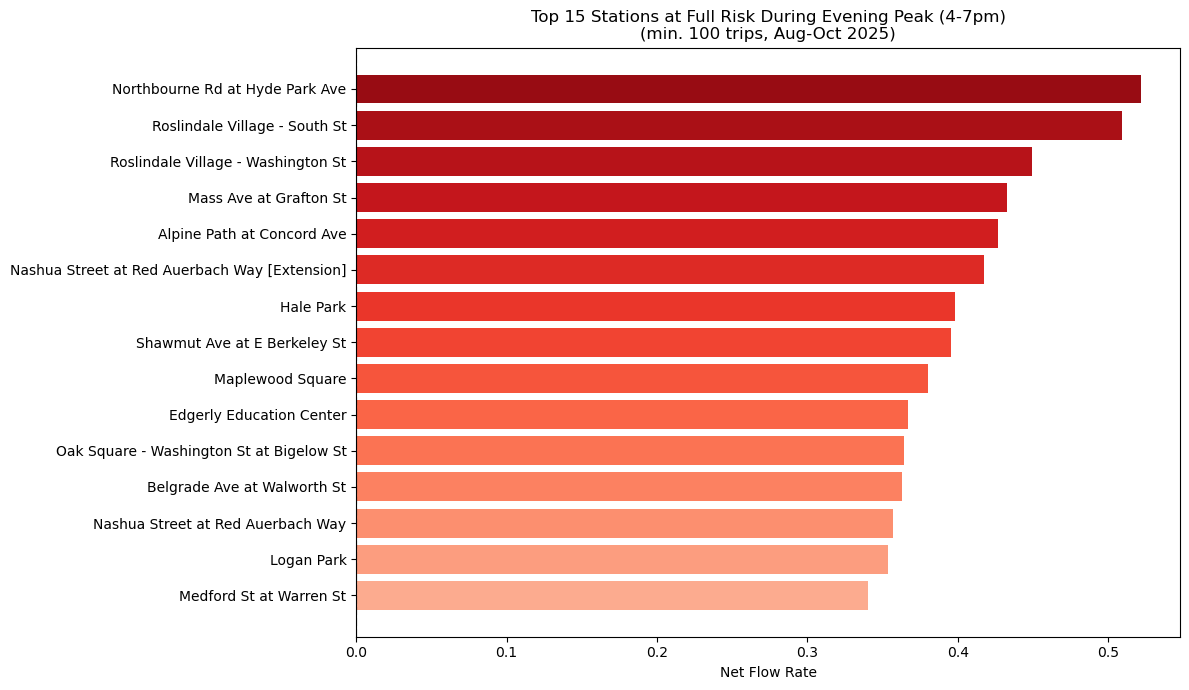

In [25]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = cm.Reds(np.linspace(0.3, 0.9, len(full_risk)))
full_risk_sorted = full_risk.sort_values("net_flow_rate")
ax.barh(full_risk_sorted["station"], full_risk_sorted["net_flow_rate"], color=colors)
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel("Net Flow Rate")
ax.set_title("Top 15 Stations at Full Risk During Evening Peak (4-7pm)\n(min. 100 trips, Aug-Oct 2025)")
plt.subplots_adjust(left=0.45)
plt.tight_layout()
plt.show()

## Conclusion:

Stations at highest full risk during evening peak (4-7pm) are concentrated in **residential neighbourhoods** - Roslindale, Hyde Park, and Jamaica Plain - as commuters return home and dock their bikes. 

Top stations by full risk (min. 100 trips, net flow rate):

| Station | Departures | Arrivals | Net Flow Rate |
|---|---|---|---|
| Northbourne Rd at Hyde Park Ave | 33 | 105 | +0.52 |
| Roslindale Village - South St | 95 | 292 | +0.51 |
| Nashua Street at Red Auerbach Way | 1,049 | 2,213 | +0.36 |
| Nashua St at Red Auerbach Way [Extension] | 724 | 1,763 | +0.42 | 

Notable **Oak Square - Washington St at Bigelow St** appears in both the empty risk (morning) and full risk (evening) lists - it empties out as commuters depart in the morning and fills back up as they return in the evening, making it the clearest example of the commuter cycle in the entire system. 

Nashua Street at Red Auerbach Way (and its extension) show the highest raw inflow volume, gaining over 2,200 net bikes combined during the evening window - likely driven by proximity to TD Garden, North Station and downtown employment centers. 

## 4. Spatial Clustering
### Do these phenomena show spatial clustering?
### For example, do patterns differ between downtown/commercial areas and residential areas?

In [17]:
#station coordinate lookup 
station_coords = df.groupby("start_station_name").agg(
    lat=("start_lat", "mean"),
    lng=("start_lng", "mean")).reset_index()
station_coords.columns = ["station", "lat", "lng"]

print(station_coords.shape)
print(station_coords.head())

(596, 3)
                 station        lat        lng
0        101 Smith Place  42.392566 -71.150759
1         1200 Beacon St  42.344143 -71.114693
2         160 Arsenal St  42.364665 -71.175685
3       175 N Harvard St  42.364475 -71.128413
4  18 Dorrance Warehouse  42.387151 -71.075978


In [18]:
morning_risk = morning_risk.merge(station_coords, on="station", how="left")
evening_risk = evening_risk.merge(station_coords, on="station", how="left")
print(morning_risk.head(3))

           station  departures  arrivals  net_flow  total  net_flow_rate  \
0  101 Smith Place        22.0      38.0      16.0   60.0       0.266667   
1   1200 Beacon St       488.0     152.0    -336.0  640.0      -0.525000   
2   160 Arsenal St       101.0     107.0       6.0  208.0       0.028846   

         lat        lng  
0  42.392566 -71.150759  
1  42.344143 -71.114693  
2  42.364665 -71.175685  


In [29]:
#spatial clustering analysis 

#defining zones based on lat/lng
def assign_zone(lat, lng):
    if lat > 42.37 and lng > -71.10:
        return "Downtown/Cambridge"
    elif lat > 42.37 and lng <= -71.10:
        return "Somerville/Medford"
    elif lat <= 42.37 and lng > -71.10:
        return "South Boston/Dorchester"
    else:
        return "Jamaica Plain/Brookline"

morning_risk["zone"] = morning_risk.apply(lambda r: assign_zone(r["lat"], r["lng"]), axis=1)
evening_risk["zone"] = evening_risk.apply(lambda r: assign_zone(r["lat"], r["lng"]), axis=1)

#Average net flow rate by zone 
print("--- MORNING (Empty Risk By Zone) ---")
print(morning_risk.groupby("zone")["net_flow_rate"].mean().sort_values())

print("--- EVENING (Full Risk By Zone) ---")
print(evening_risk.groupby("zone")["net_flow_rate"].mean().sort_values(ascending=False))

--- MORNING (Empty Risk By Zone) ---
zone
Downtown/Cambridge        -0.234453
Jamaica Plain/Brookline   -0.220236
Somerville/Medford        -0.218604
South Boston/Dorchester   -0.018933
Name: net_flow_rate, dtype: float64
--- EVENING (Full Risk By Zone) ---
zone
Somerville/Medford         0.100220
Downtown/Cambridge         0.074222
Jamaica Plain/Brookline    0.068658
South Boston/Dorchester   -0.025911
Name: net_flow_rate, dtype: float64


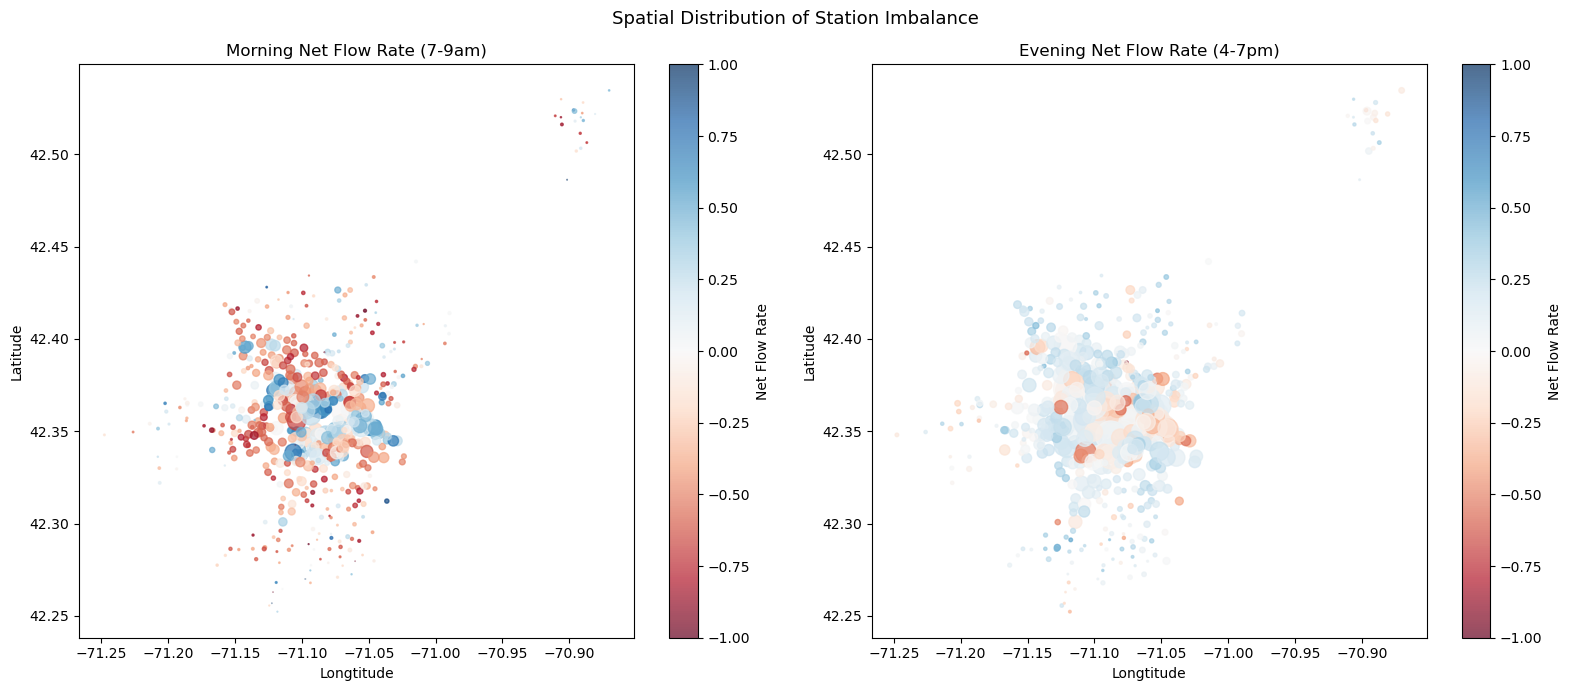

In [31]:
#visualizing spatially 

zone_colors = {
    "Downtown/Cambridge": "navy", 
    "Somerville/Medford": "green", 
    "South Boston/Dorchester": "red", 
    "Jamaica Plain/Brookline": "orange"
}

fig, axes  = plt.subplots(1, 2, figsize=(16, 7))

for ax, (flow_df, title, cmap, vmin, vmax) in zip(axes, [
    (morning_risk, "Morning Net Flow Rate (7-9am)", "RdBu", -1, 1), 
    (evening_risk, "Evening Net Flow Rate (4-7pm)", "RdBu", -1, 1)]):
    sc = ax.scatter(flow_df["lng"], flow_df["lat"], 
                    c=flow_df["net_flow_rate"],
                    cmap=cmap, vmin=vmin, vmax=vmax,
                    alpha=0.7, s=flow_df["total"]/20)
    plt.colorbar(sc, ax=ax, label="Net Flow Rate")
    ax.set_title(title)
    ax.set_xlabel("Longtitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Spatial Distribution of Station Imbalance", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion: Spatial Clustering

Spatial analysis across 594 stations reveals clear geographic clustering of 
imbalance patterns across four zones.

### Zone-Level Summary

| Zone | Morning Net Flow Rate | Evening Net Flow Rate |
|---|---|---|
| Downtown / Cambridge | −0.234 | +0.074 |
| Jamaica Plain / Brookline | −0.220 | +0.069 |
| Somerville / Medford | −0.219 | +0.100 |
| South Boston / Dorchester | −0.019 | −0.026 |

### Key Findings

- **Downtown/Cambridge** shows the highest morning drain rate (−0.234), suggesting 
  many trips originate near downtown and flow further inward toward employment and 
  transit hubs.

- **Jamaica Plain/Brookline** shows the second highest morning drain (−0.220), 
  confirming its role as a residential commuter origin zone where bikes leave rapidly 
  toward the urban core.

- **Somerville/Medford** shows the highest evening accumulation (+0.100), confirming 
  it as the strongest residential return destination in the system.

- **South Boston/Dorchester** is the outlier — showing the mildest morning drain 
  (−0.019) and a slightly negative evening rate (−0.026), suggesting more balanced, 
  localized trip patterns rather than long commuter flows into the urban core.

### Spatial Pattern
The scatter plots confirm spatial clustering is present — red (outflow) stations 
cluster in outer neighborhoods during the morning, while the evening plot shows a 
partial reversal with blue (inflow) shifting outward. This is consistent with a 
classic hub-and-spoke commuter pattern where bikes flow inward in the morning and 
outward in the evening. South Boston/Dorchester is a notable exception, behaving 
independently of this pattern.

## Other Analysis through visualizations:

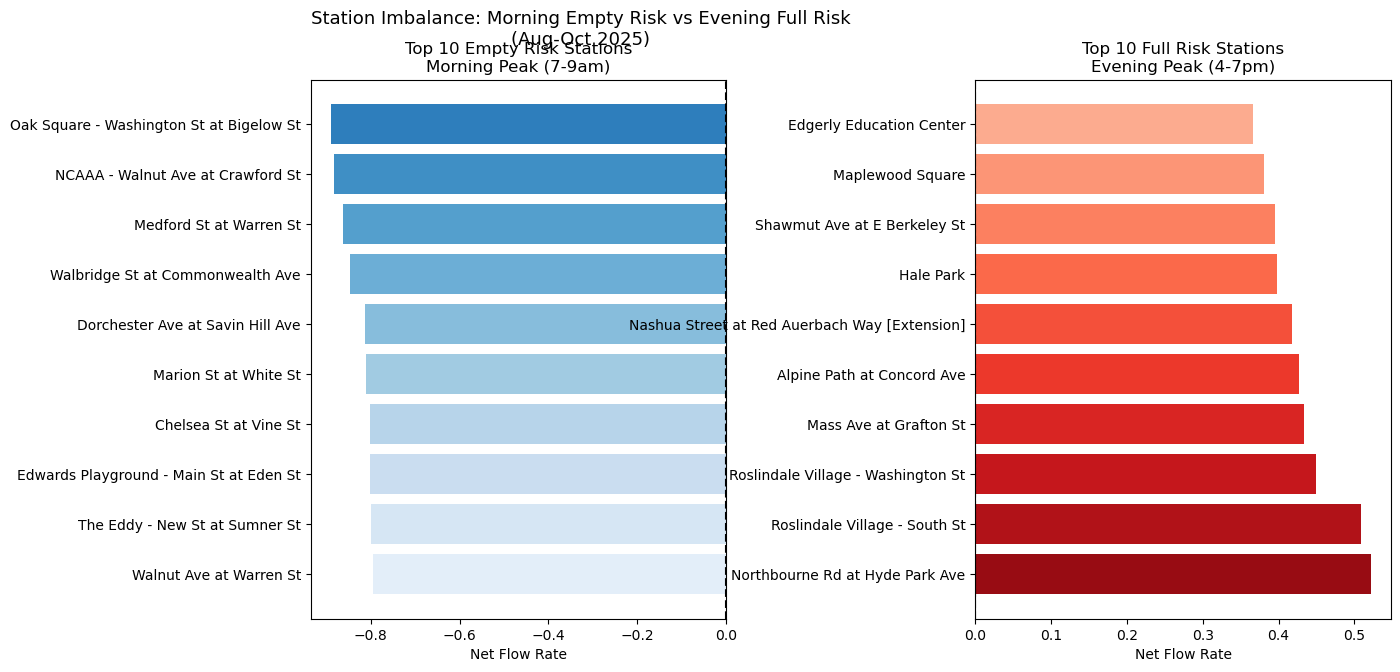

In [32]:
#Top 10 most imbalanced stations

#getting top 10 empty risk (morning) and top 10 full risk (evening)
top_empty = morning_risk[morning_risk["total"] >= 100].sort_values("net_flow_rate").head(10)
top_full = evening_risk[evening_risk["total"] >= 100].sort_values("net_flow_rate", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#Morning - Emoty Risk 
axes[0].barh(top_empty["station"], top_empty["net_flow_rate"], 
             color=cm.Blues_r(np.linspace(0.3, 0.9, len(top_empty))))
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Top 10 Empty Risk Stations\nMorning Peak (7-9am)")
axes[0].set_xlabel("Net Flow Rate")
axes[0].invert_yaxis()

#Evening - Full Risk 
axes[1].barh(top_full.sort_values("net_flow_rate")["station"], 
             top_full.sort_values("net_flow_rate")["net_flow_rate"], 
             color=cm.Reds(np.linspace(0.3, 0.9, len(top_full))))
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Top 10 Full Risk Stations\nEvening Peak (4-7pm)")
axes[1].set_xlabel("Net Flow Rate")
axes[1].invert_yaxis()

plt.suptitle("Station Imbalance: Morning Empty Risk vs Evening Full Risk\n(Aug-Oct 2025)", fontsize=13)
plt.subplots_adjust(left=0.35, right=0.95, wspace=0.6)
plt.show()

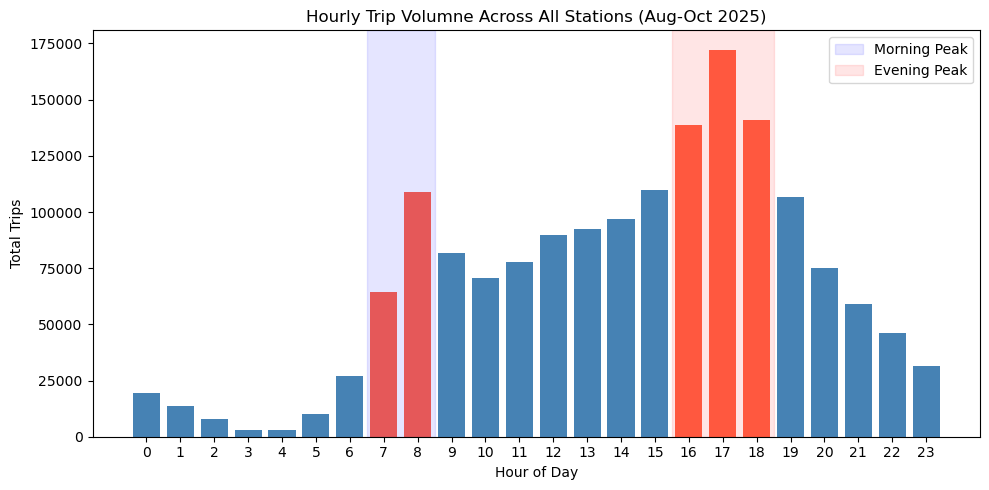

In [33]:
#hourly trip volume 
hourly = df.groupby("start_hour").size().reset_index(name="trips")

plt.figure(figsize=(10, 5))
bars = plt.bar(hourly["start_hour"], hourly["trips"], 
               color=["tomato" if h in [7, 8, 16, 17, 18] else "steelblue" for h in hourly["start_hour"]])
plt.axvspan(6.5, 8.5, alpha=0.1, color="blue", label="Morning Peak")
plt.axvspan(15.5, 18.5, alpha=0.1, color="red", label="Evening Peak")
plt.xlabel("Hour of Day")
plt.ylabel("Total Trips")
plt.title("Hourly Trip Volumne Across All Stations (Aug-Oct 2025)")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
!pip install folium

In [35]:
import folium

# Merge coords into both risk tables (already done, just making sure)
all_stations = morning_risk[["station", "lat", "lng", "net_flow_rate", "total"]].copy()
all_stations = all_stations.rename(columns={"net_flow_rate": "morning_rate", "total": "morning_total"})

eve_merge = evening_risk[["station", "net_flow_rate", "total"]].rename(
    columns={"net_flow_rate": "evening_rate", "total": "evening_total"})

combined = all_stations.merge(eve_merge, on="station", how="outer")
combined = combined.dropna(subset=["lat", "lng"])

m = folium.Map(location=[42.36, -71.08], zoom_start=12, tiles="CartoDB positron")

for _, row in combined.iterrows():
    morning_rate = row["morning_rate"] if not pd.isna(row["morning_rate"]) else 0
    evening_rate = row["evening_rate"] if not pd.isna(row["evening_rate"]) else 0
    total = row["morning_total"] if not pd.isna(row["morning_total"]) else 50

    if morning_rate < -0.5:
        color = "darkred"
    elif morning_rate < -0.2:
        color = "red"
    elif morning_rate < 0:
        color = "orange"
    elif morning_rate < 0.2:
        color = "lightblue"
    else:
        color = "blue"

    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=max(3, total / 200),   # ← reduced from /80 to /200
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['station']}</b><br>"
            f"Morning rate: {morning_rate:.3f}<br>"
            f"Evening rate: {evening_rate:.3f}<br>"
            f"Morning trips: {int(total)}",
            max_width=250
        )
    ).add_to(m)

# Add legend as HTML
legend_html = """
<div style="position: fixed; 
     bottom: 50px; left: 50px; 
     width: 220px;
     z-index: 9999;
     background-color: white; 
     padding: 12px; 
     border-radius: 8px;
     border: 2px solid grey; 
     font-size: 12px;
     box-shadow: 3px 3px 6px rgba(0,0,0,0.3);">
<b>Morning Net Flow Rate</b><br><br>
<span style="color:darkred; font-size:16px;">●</span> Severe empty risk (&lt; -0.5)<br>
<span style="color:red; font-size:16px;">●</span> Moderate empty risk (-0.5 to -0.2)<br>
<span style="color:orange; font-size:16px;">●</span> Mild empty risk (-0.2 to 0)<br>
<span style="color:lightblue; font-size:16px;">●</span> Mild accumulation (0 to 0.2)<br>
<span style="color:blue; font-size:16px;">●</span> Strong accumulation (&gt; 0.2)<br><br>
<i>Circle size = morning trip volume</i>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))
m

An interactive folium map was created displaying all 594 BlueBikes stations across the Boston metro area, with each station colored by its morning net flow rate and sized by activity volume. 

### Color Legend
| Color | Morning Net Flow Rate | Risk Type |
|---|---|---|
| Dark Red | < -0.50 | Severe empty risk |
| Red | -0.50 to -0.20 | Moderate empty risk |
| Orange | -0.20 to 0.00 | Mild empty risk |
| Light Blue | 0.00 to 0.20 | Mild accumulation |
| Blue | > 0.20 | Strong accumulation |

### Key Spatial Observations 

- **Downtown Boston adn Cambridge** are dominated by large blue circles - high-volumne stations that accumulate bikes in the morning, confirming their role as commuter destinations.
- **Outer neighhborhoods** (Jamaica Plain, Dorchester, Somerville, Chelsea) show predominantly dark red and red circles - stations that drain heavily during the morning peak as residents begin their commute inward.
- **The size contrast is striking** - downtown stations are much larger (higher volumne) than outer stations, reflectig the concentration of Bluebikes activity in the urbna core.
- Each station popup displays its morning rate, evening rate and trip volumne, enabling sttion-level inspection of imbalance across the entire system.

### Conclusion
The map confirms that Bluebikes imbalance is not random - if follows a clear geographic pattern consistent with racdial commuting behavior. Rebalancing efforts should prioritize moving bikes from downtown accumulation zones back to outer residential stations overnight to prepare for the next morning's commute. 
